# 05 Evaluation Report

Notebook này tổng hợp các bảng kết quả và log cuối cùng để phục vụ viết báo cáo.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import load_params, resolve_path, resolve_table_directory

config = load_params()
tables_dir = resolve_table_directory(config, 'core', PROJECT_ROOT)
logs_dir = resolve_path(config['paths']['logs_dir'], PROJECT_ROOT)
reports_dir = resolve_path(config['paths']['reports_dir'], PROJECT_ROOT)
figures_dir = resolve_path(config['paths']['figures_dir'], PROJECT_ROOT)

association_rules = pd.read_csv(tables_dir / 'association_rules.csv')
clustering = pd.read_csv(tables_dir / 'clustering_comparison.csv')
classification = pd.read_csv(tables_dir / 'classification_comparison.csv')
forecasting = pd.read_csv(tables_dir / 'forecast_comparison.csv')
best_runs_summary = (logs_dir / 'best_runs_summary.md').read_text(encoding='utf-8')
results_log = (reports_dir / 'RESULTS_LOG.md').read_text(encoding='utf-8')

print('Association rows:', len(association_rules))
print('Clustering rows:', len(clustering))
print('Classification rows:', len(classification))
print('Forecasting rows:', len(forecasting))


Association rows: 12
Clustering rows: 22
Classification rows: 3
Forecasting rows: 5


In [2]:
print('Association top')
display(association_rules.head(5))
print('Clustering top')
display(clustering.head(5))
print('Classification top')
display(classification.head(5))
print('Forecasting top')
display(forecasting.head(5))


Association top


,antecedent,consequent,antecedent_size,consequent_size,support,confidence,lift,algorithm,item_level
0,"Binders, Paper",Storage,2,1,0.010565,0.194757,1.254701,apriori,Sub-Category
1,Storage,"Binders, Paper",1,2,0.010565,0.068063,1.254701,apriori,Sub-Category
2,"Binders, Paper",Phones,2,1,0.010768,0.198502,1.216720,apriori,Sub-Category
3,Phones,"Binders, Paper",1,2,0.010768,0.066002,1.216720,apriori,Sub-Category
4,"Paper, Phones",Binders,2,1,0.010768,0.313609,1.195651,apriori,Sub-Category


Clustering top


,algorithm,k,eps,min_samples,silhouette,davies_bouldin,min_cluster_share,max_cluster_share,noise_share,accepted_for_report,feature_count,features
0,kmeans,4,NaN,NaN,0.389521,1.011043,0.081967,0.614124,0.0,True,5,"recency_days, total_sales, avg_order_value, ac..."
1,kmeans,3,NaN,NaN,0.354054,1.169021,0.150063,0.655738,0.0,True,5,"recency_days, total_sales, avg_order_value, ac..."
2,kmeans,2,NaN,NaN,0.341247,1.428355,0.302648,0.697352,0.0,True,5,"recency_days, total_sales, avg_order_value, ac..."
3,agglomerative,4,NaN,NaN,0.315016,1.143918,0.060530,0.538462,0.0,True,5,"recency_days, total_sales, avg_order_value, ac..."
4,agglomerative,3,NaN,NaN,0.284043,1.308295,0.220681,0.538462,0.0,True,5,"recency_days, total_sales, avg_order_value, ac..."


Classification top


,model,accuracy,f1_macro,f1_weighted,roc_auc_ovr,params
0,logistic_regression,0.386935,0.369547,0.396632,0.548107,"{'C': 10.0, 'class_weight': 'balanced'}"
1,decision_tree,0.427136,0.346540,0.407274,0.515597,"{'max_depth': 5, 'min_samples_leaf': 3, 'class..."
2,random_forest,0.432161,0.327754,0.403686,0.491491,"{'n_estimators': 100, 'max_depth': None, 'min_..."


Forecasting top


,model,status,MAE,RMSE,sMAPE
0,holt_winters,ok,13133.389642,18419.610063,18.725010
1,sarimax,ok,20260.639786,25542.927647,29.082786
2,naive,ok,31636.566033,37862.673859,45.629744
3,moving_average,ok,36185.879167,42565.872804,54.739688
4,prophet,unavailable: prophet is not installed in the c...,NaN,NaN,NaN


In [3]:
print(best_runs_summary)

# Best Runs Summary

## association
- run_id: `association-20260320-224153`
- run_time: `2026-03-20 22:41:53`
- metric_chinh: `avg_lift_top5` = `1.2276986`
- conclusion: **tốt hơn các run cùng phiên bản dữ liệu**

## clustering
- run_id: `clustering-20260320-224203`
- run_time: `2026-03-20 22:42:03`
- metric_chinh: `silhouette` = `0.38952090303089726`
- conclusion: **tốt hơn các run cùng phiên bản dữ liệu**

## classification
- run_id: `classification-20260320-224204`
- run_time: `2026-03-20 22:42:04`
- metric_chinh: `f1_macro` = `0.369547`
- conclusion: **chưa có đối chứng**

## forecasting
- run_id: `forecasting-20260320-224205`
- run_time: `2026-03-20 22:42:05`
- metric_chinh: `sMAPE` = `18.72501`
- conclusion: **tốt hơn các run cùng phiên bản dữ liệu**



In [4]:
print(results_log[:2000])

# RESULTS LOG

File nay ghi theo dang doc tay de phuc vu viet bao cao.

## Ket qua 01

- run_id: `association-20260314-194445`
- run_time: `2026-03-14 19:44:45`
- task: `association`
- dataset_version: `train.csv|2129689B|2020-09-11 15:40:16`
- code_version: `a728db5`
- split_strategy: `basket grouped by Order ID`
- metrics: `{"rule_count": 2, "max_lift": 1.193768, "avg_lift_top5": 1.1208985}`
- key_params: `{"min_support": 0.02, "min_confidence": 0.2, "min_lift": 1.0, "max_length": 3, "top_n_rules": 20}`
- output_paths: `{"itemsets": "D:\\CODE\\DNU_Data_Mining\\DataminingSupperMarketSales\\outputs\\tables\\association_itemsets.csv", "rules": "D:\\CODE\\DNU_Data_Mining\\DataminingSupperMarketSales\\outputs\\tables\\association_rules.csv", "top_categories_figure": "D:\\CODE\\DNU_Data_Mining\\DataminingSupperMarketSales\\outputs\\figures\\top_subcategories.png"}`
- notes: Association rules over basket transactions using configured item level.
- conclusion: **chua on**

## Ket qua 02

- r


Top sub-categories by sales


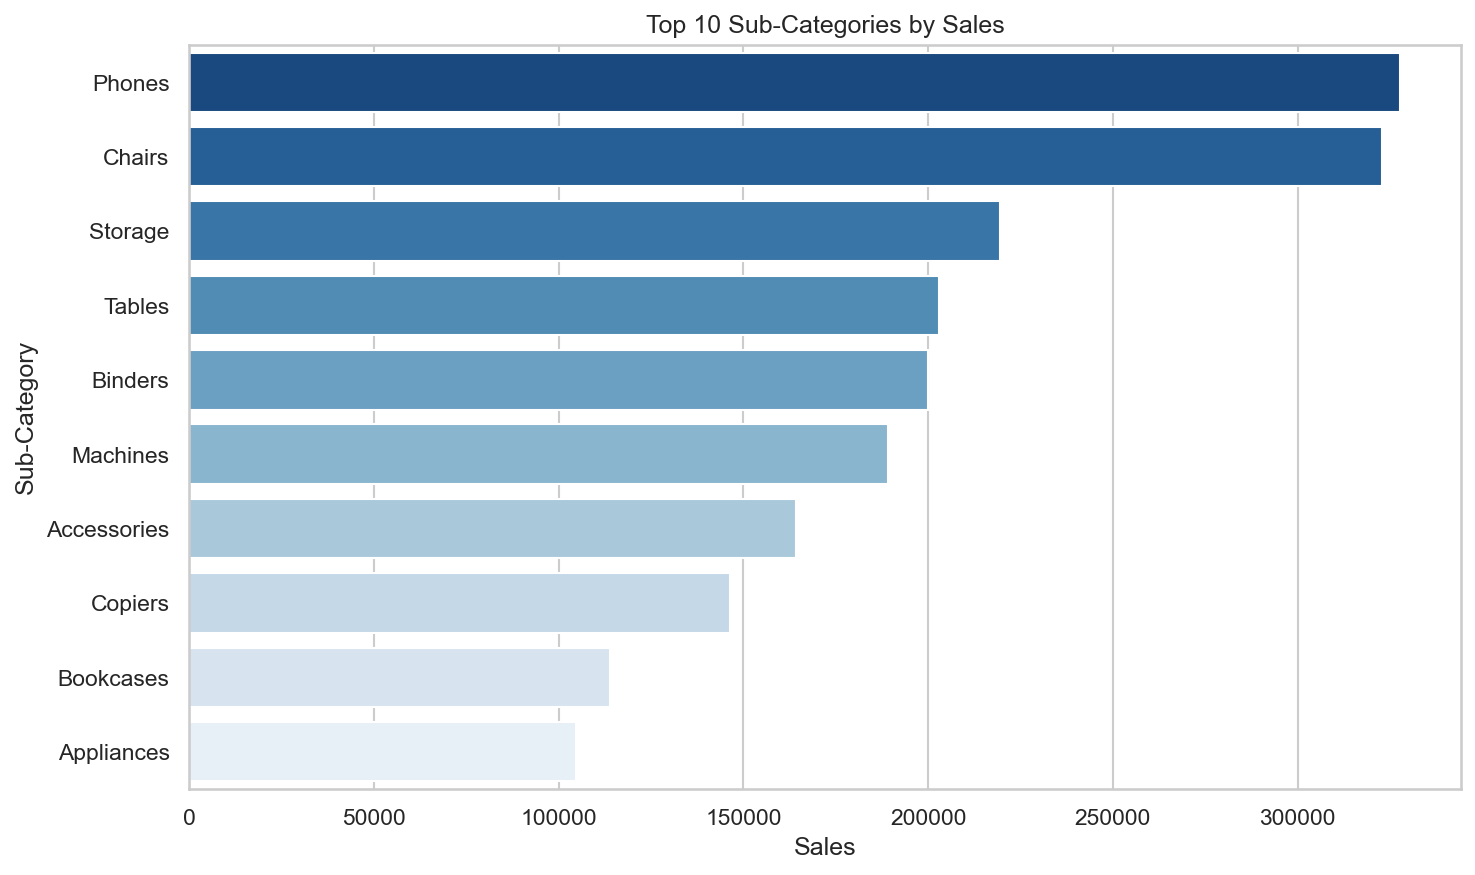


Sales over time


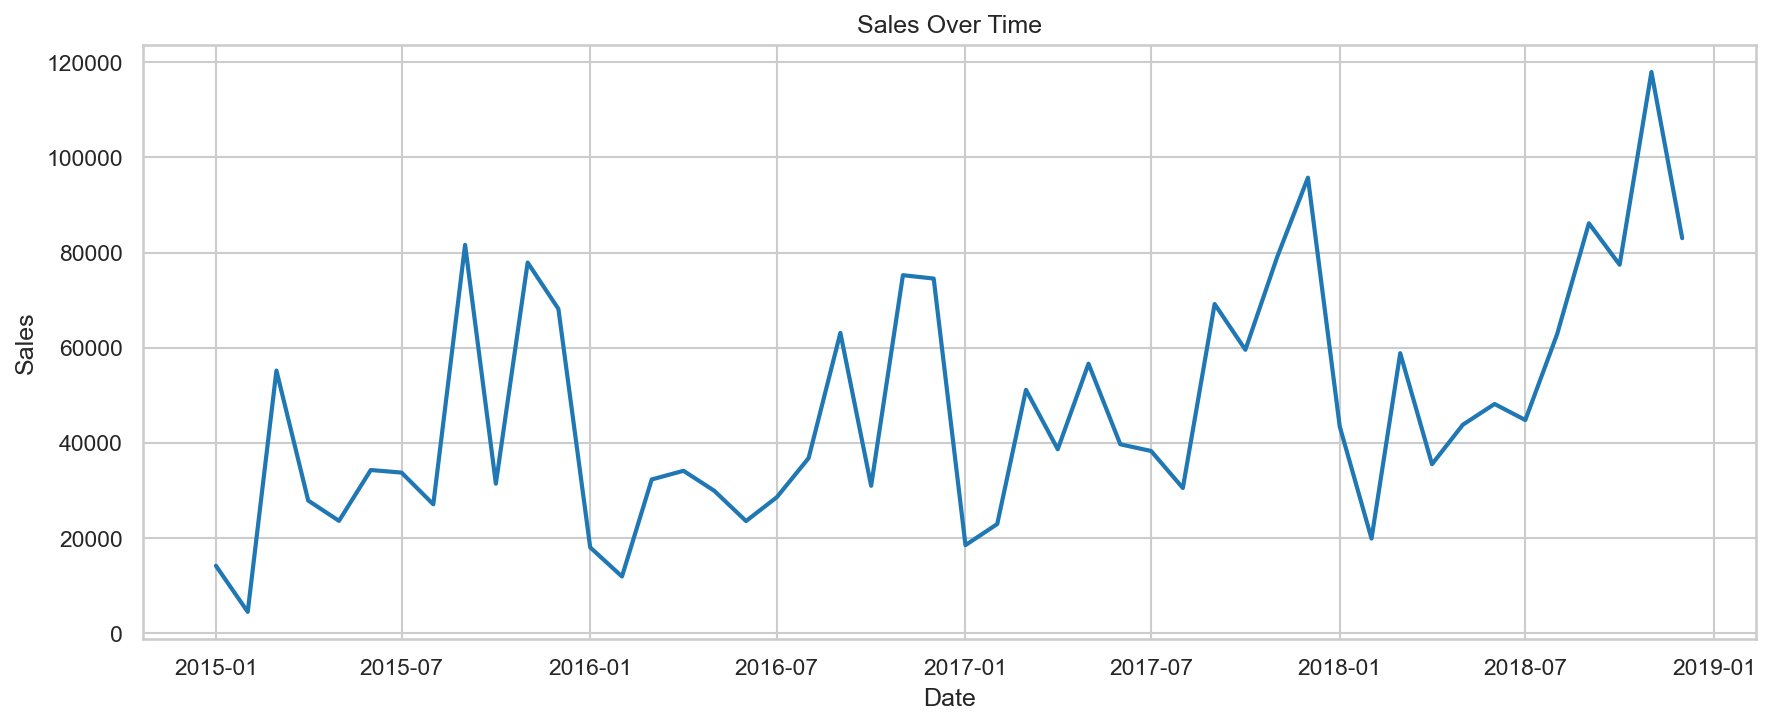


Cluster profile


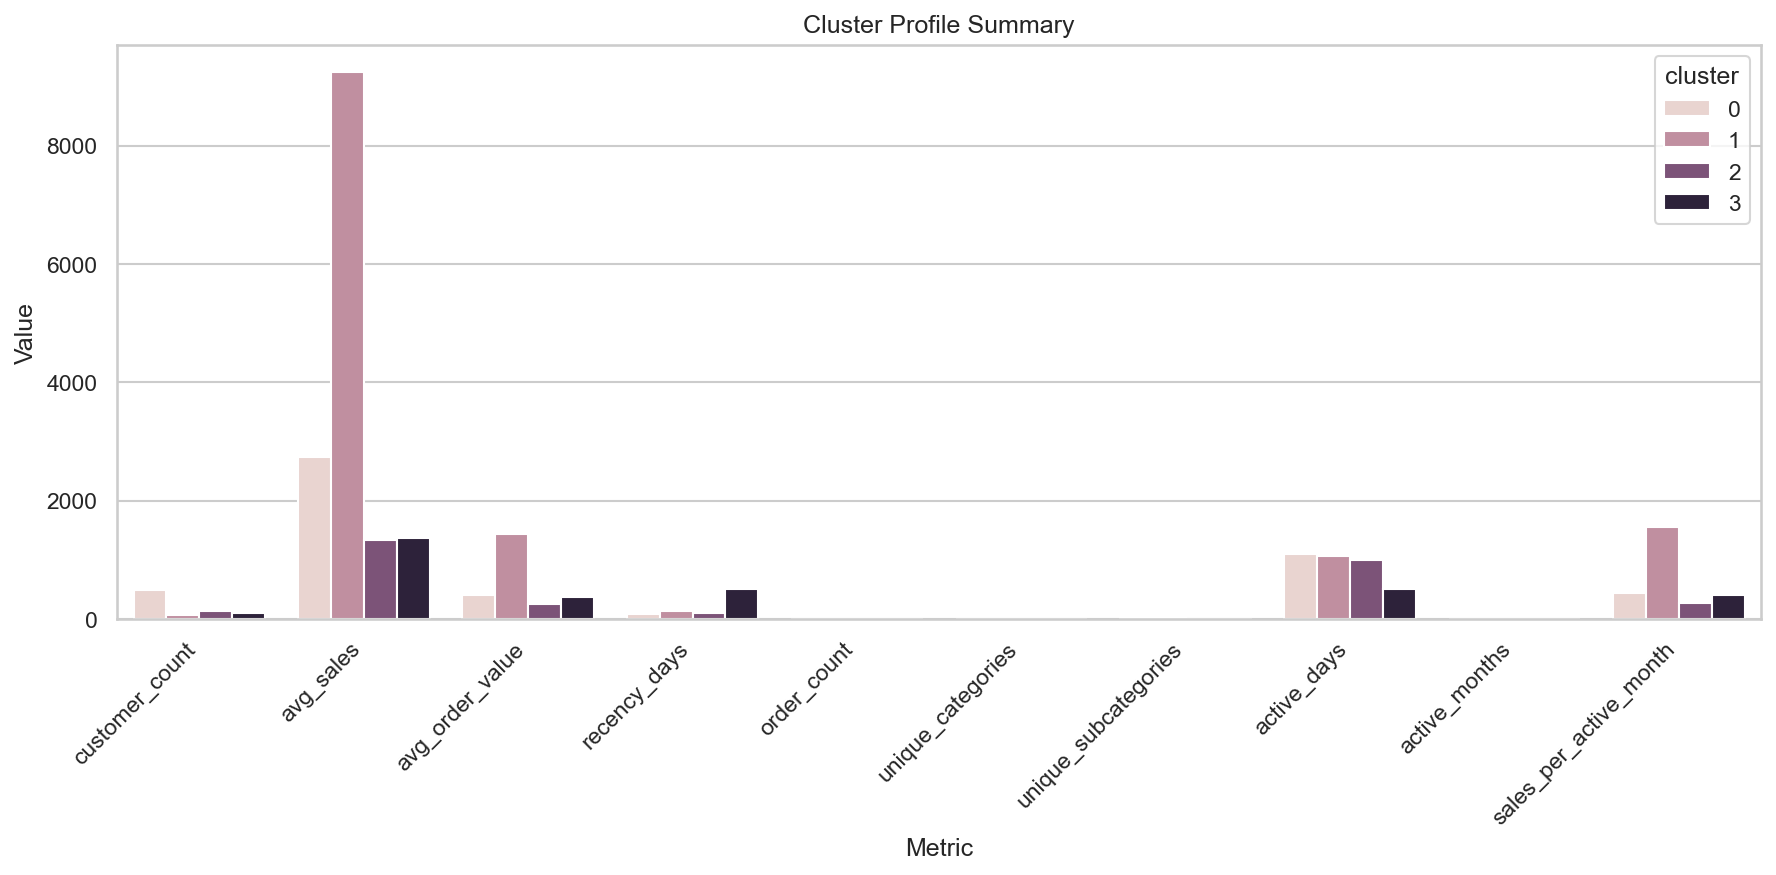


Classification confusion matrix


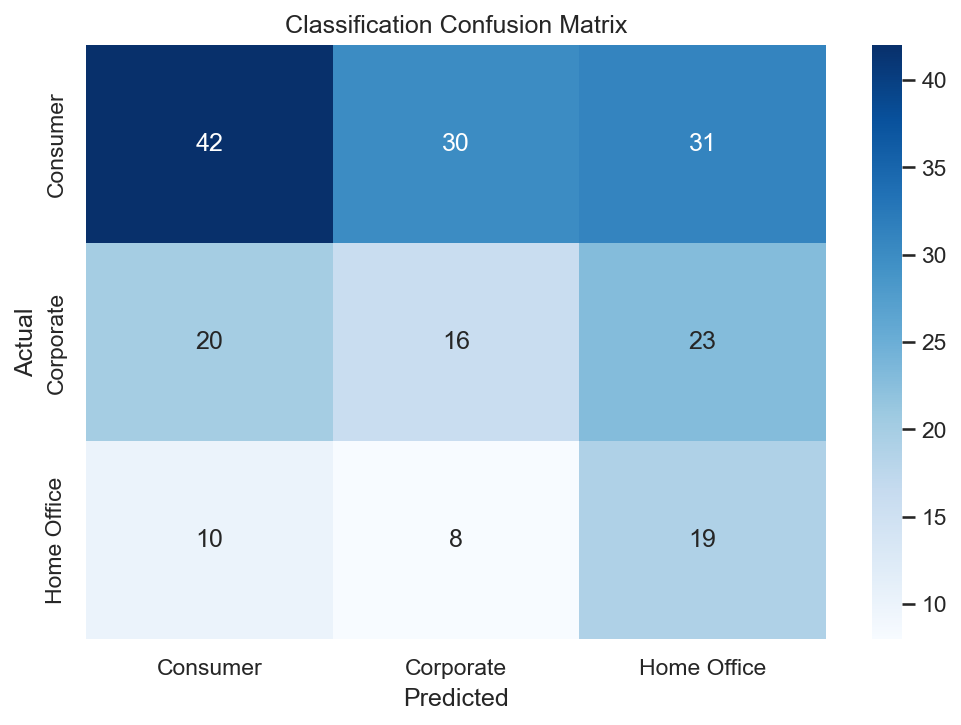


Forecast vs actual


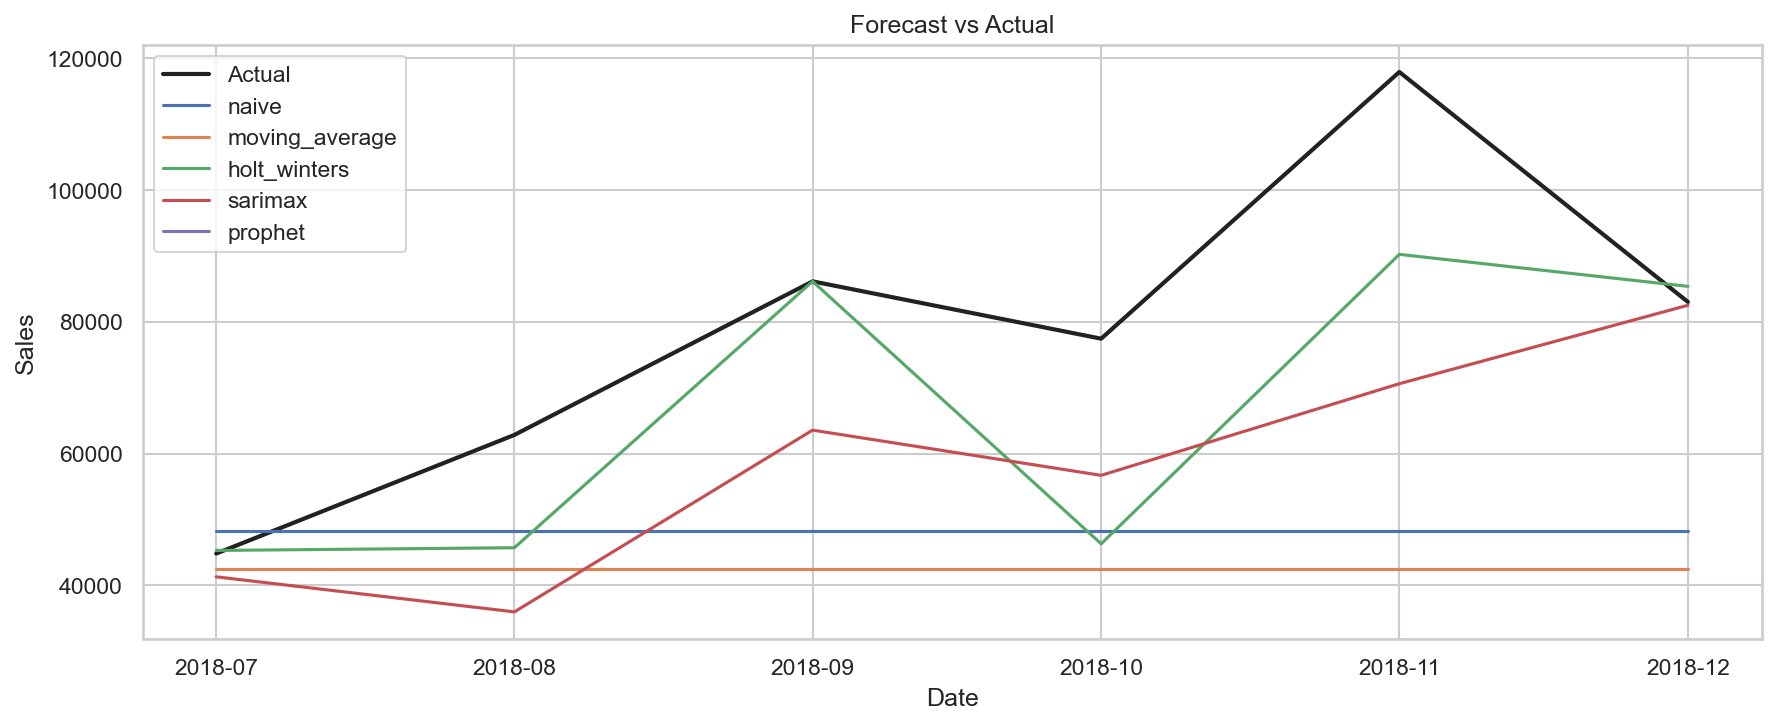

In [5]:
for title, filename in [
    ('Top sub-categories by sales', 'top_subcategories.png'),
    ('Sales over time', 'weekly_sales.png'),
    ('Cluster profile', 'cluster_profile.png'),
    ('Classification confusion matrix', 'classification_confusion_matrix.png'),
    ('Forecast vs actual', 'forecast_vs_actual.png'),
]:
    path = figures_dir / filename
    print(f'\n{title}')
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print(f'Missing figure: {path}')
